In [ ]:
# import json
# import ijson

# with open(r""path/to/my/file", "r") as infile, open("public_v2.ndjson", "w") as outfile:
#     for key, value in ijson.kvitems(infile, ''):
#         value["log_id"] = key
#         outfile.write(json.dumps(value) + "\n")

In [59]:
import duckdb
import pandas as pd

con = duckdb.connect()

# Limitiamo a 10.000 righe per velocità
df = con.execute("""
    SELECT *
    FROM read_json_auto('public_v2.ndjson')
    LIMIT 100000
""").df()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   referrer   100000 non-null  str  
 1   request    100000 non-null  str  
 2   method     99256 non-null   str  
 3   resource   99256 non-null   str  
 4   bytes      100000 non-null  str  
 5   response   100000 non-null  str  
 6   ip         100000 non-null  str  
 7   useragent  100000 non-null  str  
 8   timestamp  100000 non-null  str  
 9   log_id     100000 non-null  str  
dtypes: str(10)
memory usage: 7.6 MB


In [60]:
# %% [2] - Aggiungiamo pochi attacchi artificiali
attacks = [
    {
        "referrer": "http://search.lib.auth.gr/Search/<script>alert('XSS')</script>",
        "request": "search.lib.auth.gr:80 185.22.12.44 - - [01/Mar/2018:00:00:15 +0200] GET /Search?q=<script>alert('XSS')</script> HTTP/1.1 400 1200 http://search.lib.auth.gr/Search/<script>alert('XSS')</script> Mozilla/5.0",
        "method": "GET",
        "resource": "/Search?q=<script>alert('XSS')</script>",
        "bytes": "1200",
        "response": "400",
        "ip": "185.22.12.44",
        "useragent": "Mozilla/5.0",
        "timestamp": "2018-02-28T22:00:15.000Z",
        "log_id": "attack_xss"
    },
    {
        "referrer": "http://evil.com",
        "request": "search.lib.auth.gr:80 45.77.88.12 - - [01/Mar/2018:00:00:20 +0200] GET /login?user=admin' OR 1=1-- HTTP/1.1 500 800 http://evil.com Mozilla/5.0",
        "method": "GET",
        "resource": "/login?user=admin' OR 1=1--",
        "bytes": "800",
        "response": "500",
        "ip": "45.77.88.12",
        "useragent": "Mozilla/5.0",
        "timestamp": "2018-02-28T22:00:20.000Z",
        "log_id": "attack_sql"
    },
    {
        "referrer": "-",
        "request": "search.lib.auth.gr:80 91.200.12.77 - - [01/Mar/2018:00:00:25 +0200] GET /../../../../etc/passwd HTTP/1.1 403 300 - curl/7.58.0",
        "method": "GET",
        "resource": "/../../../../etc/passwd",
        "bytes": "300",
        "response": "403",
        "ip": "91.200.12.77",
        "useragent": "curl/7.58.0",
        "timestamp": "2018-02-28T22:00:25.000Z",
        "log_id": "attack_traversal"
    },
    {
        "referrer": "-",
        "request": "search.lib.auth.gr:80 203.0.113.45 - - [01/Mar/2018:00:00:30 +0200] GET /wp-admin/install.php HTTP/1.1 404 250 - sqlmap/1.7",
        "method": "GET",
        "resource": "/wp-admin/install.php",
        "bytes": "250",
        "response": "404",
        "ip": "203.0.113.45",
        "useragent": "sqlmap/1.7",
        "timestamp": "2018-02-28T22:00:30.000Z",
        "log_id": "attack_scanner"
    }
]

df = pd.concat([df, pd.DataFrame(attacks)], ignore_index=True)

df["timestamp"] = pd.to_datetime(df["timestamp"])


In [61]:
#lughezza della resource richiesta

df["resource_len"] = df["resource"].str.len()
df.shape

(100004, 11)

In [62]:
#da valutare se devo fare un primo controllo anche io sui quartili
from anomalies_detector import has_suspicious_request_len

df = has_suspicious_request_len(df)

df.shape

(99260, 12)

In [63]:
#troppi special characters
df["special_chars"] = df["request"].str.count(r"[<>\'\"%;(){}]*+@")
df["special_chars"].value_counts()

special_chars
0    95304
1     3956
Name: count, dtype: int64

In [64]:
#directory traversale
df["has_traversal"] = df["request"].str.contains(r"\.\./", regex=True, na=False).astype(int)
df["has_traversal"].value_counts()

has_traversal
0    99259
1        1
Name: count, dtype: int64

In [65]:
# sql injection

df["has_sql_keywords"] = df["request"].str.contains(
    r"union|select|insert|drop|or 1=1|--|admin",
    case=False,
    na=False
).astype(int)

df["has_sql_keywords"].value_counts()

has_sql_keywords
0    99258
1        2
Name: count, dtype: int64

In [66]:
#script injection
df["has_script_tag"] = df["request"].str.contains(
    r"<script>",
    case=False,
    na=False
).astype(int)
df["has_script_tag"].value_counts()

has_script_tag
0    99259
1        1
Name: count, dtype: int64

In [67]:
#possibile scanner da parte di bot
df["scanner_agent"] = df["useragent"].str.contains(
    r"sqlmap|nikto|curl|nmap|dirbuster",
    case=False,
    na=False
).astype(int)
df["useragent"].value_counts()

useragent
Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/64.0.3282.186 Safari/537.36                                                                                     15210
TurnitinBot (https://turnitin.com/robot/crawlerinfo.html)                                                                                                                                                7596
BUbiNG (+http://law.di.unimi.it/BUbiNG.html)                                                                                                                                                             7077
Mozilla/5.0 (Windows NT 6.1; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/64.0.3282.186 Safari/537.36                                                                                       5577
Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:58.0) Gecko/20100101 Firefox/58.0                                                                                        

In [68]:
# status code di errore
df["is_error"] = (df["response"].astype(int) >= 400).astype(int)

df['is_error'].value_counts()

is_error
0    99103
1      157
Name: count, dtype: int64

In [69]:
# numero di query eccessivo
df["num_params"] = df["resource"].str.count("=")
df["num_params"].value_counts()

num_params
0    87127
1    11985
5       97
4       31
3       13
6        5
2        2
Name: count, dtype: int64

In [70]:
# numero di richieste per IP
df["requests_per_ip"] = df.groupby("ip")["ip"].transform("count")


In [71]:
import numpy as np

def entropy(s):
    prob = [float(s.count(c)) / len(s) for c in dict.fromkeys(list(s))]
    entropy = -sum([p * np.log2(p) for p in prob])
    return entropy


df["request_entropy"] = df["request"].apply(lambda x: entropy(str(x)))


In [72]:
df['bytes_num'] = pd.to_numeric(df['bytes'], errors='coerce').fillna(0)
resource_avg_bytes = df.groupby('resource')['bytes_num'].transform('mean')

df['bytes_ratio'] = df['bytes_num'] / (resource_avg_bytes + 1)
df['bytes_ratio'].value_counts()

bytes_ratio
0.998525    16228
0.998527     4551
0.997222     3738
0.997963     2704
0.997230      758
            ...  
0.999958        1
0.999914        1
0.999947        1
0.996678        1
0.996016        1
Name: count, Length: 17105, dtype: int64

In [73]:
df['is_image'] = df['resource'].str.contains(r'\.(jpg|jpeg|png|gif|svg)', case=False, na=False).astype(int)

C:\Users\6060650\AppData\Local\Temp\ipykernel_23788\693450122.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_image'] = df['resource'].str.contains(r'\.(jpg|jpeg|png|gif|svg)', case=False, na=False).astype(int)


In [74]:
df.info()

<class 'pandas.DataFrame'>
Index: 99260 entries, 0 to 100003
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   referrer                    99260 non-null  str                
 1   request                     99260 non-null  str                
 2   method                      99260 non-null  str                
 3   resource                    99260 non-null  str                
 4   bytes                       99260 non-null  str                
 5   response                    99260 non-null  str                
 6   ip                          99260 non-null  str                
 7   useragent                   99260 non-null  str                
 8   timestamp                   99260 non-null  datetime64[us, UTC]
 9   log_id                      99260 non-null  str                
 10  resource_len                99260 non-null  int64              
 11  has_

DA QUI IN POI ABBIAMO L'ALGORITMO DI ISOLATION FOREST
1. L'algoritmo non accetta stringhe o date. Dobbiamo isolare solo le colonne numeriche (quelle che hai creato con tanta cura).


In [75]:
from sklearn.ensemble import IsolationForest

# Definiamo le colonne che l'algoritmo deve "studiare"
features = [
    'resource_len', 'has_suspicious_request_len', 'special_chars',
    'has_traversal', 'has_sql_keywords', 'has_script_tag',
    'scanner_agent', 'is_error', 'num_params',
    'requests_per_ip', 'request_entropy', 'bytes_num',
    'bytes_ratio', 'is_image'
]

X = df[features]

2. Configurazione e Addestramento
L'Isolation Forest funziona creando alberi decisionali casuali: le anomalie vengono "isolate" più velocemente (richiedono meno biforcazioni).


In [76]:
# contamination è la % stimata di attacchi nel dataset (es. 0.1% = 0.001)
model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# Addestramento
df['anomaly_score'] = model.fit_predict(X)

# Risultato: -1 significa Anomalia, 1 significa Traffico Normale

3. Interpretazione dei risultati
Oltre al flag -1/1, è utilissimo guardare il decision_function, che dà un punteggio continuo: più è basso, più la richiesta è "strana".


In [77]:
# Punteggio grezzo: valori negativi = più anomalo
df['scores'] = model.decision_function(X)

# Vediamo se i tuoi attacchi artificiali sono stati scovati
print(df[df['log_id'].str.contains('attack')][['log_id', 'anomaly_score', 'scores']])

                  log_id  anomaly_score    scores
100000        attack_xss              1  0.024591
100001        attack_sql              1  0.013331
100002  attack_traversal              1  0.016883
100003    attack_scanner              1  0.013343


4. Verifica dei Falsi Positivi
Ordina il dataset per il punteggio più basso per vedere cosa l'algoritmo considera "peggiore" tra i dati reali:

In [78]:
# Mostra le 10 richieste più sospette del dataset
top_anomalies = df.sort_values(by='scores').head(10)
print(top_anomalies[['request', 'scores']])

                                                 request    scores
14821  search.lib.auth.gr:80 54.80.50352 - - [01/Mar/... -0.078716
58978  search.lib.auth.gr:80 216.244.40675 - - [01/Ma... -0.078070
17912  search.lib.auth.gr:80 221.158.39459 - - [01/Ma... -0.075911
41246  search.lib.auth.gr:80 94.67.49161 - - [01/Mar/... -0.065967
80660  search.lib.auth.gr:80 147.95.41606 - - [01/Mar... -0.063299
13660  search.lib.auth.gr:80 216.244.58782 - - [01/Ma... -0.061477
7755   search.lib.auth.gr:80 216.244.49318 - - [01/Ma... -0.060837
18582  search.lib.auth.gr:80 216.244.49318 - - [01/Ma... -0.060837
29176  search.lib.auth.gr:80 216.244.58782 - - [01/Ma... -0.059592
45609  search.lib.auth.gr:80 155.207.31329 - - [01/Ma... -0.058865


Dato che ho inserito degli attacchi manualmente (attack_xss, attack_sql, ecc.), posso calcolare una Matrice di Confusione semplificata per dimostrare quanto l'algoritmo è efficace nel trovare "l'ago nel pagliaio" che ho nascosto io.


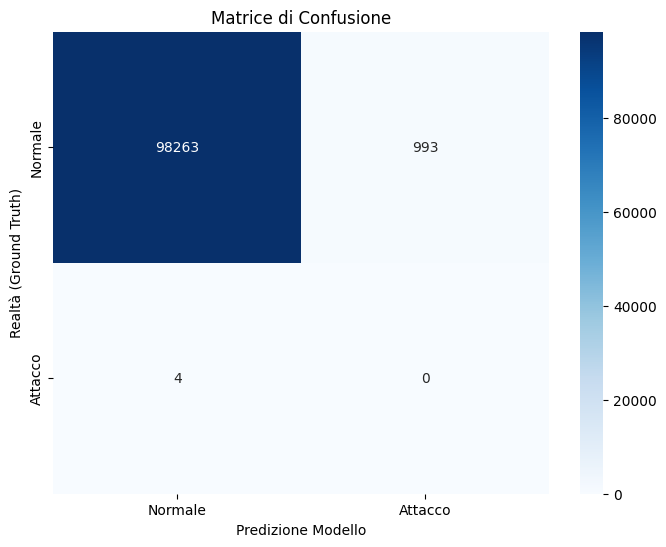

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     99256
           1       0.00      0.00      0.00         4

    accuracy                           0.99     99260
   macro avg       0.50      0.49      0.50     99260
weighted avg       1.00      0.99      0.99     99260



In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


# 1. Creiamo una colonna "realtà" (y_true)
# Assumiamo che tutto sia normale (0) tranne i log_id che iniziano con 'attack' (1)
df['is_attack_real'] = df['log_id'].str.contains('attack').astype(int)

# 2. Trasformiamo la predizione dell'Isolation Forest (y_pred)
# L'algoritmo sputa -1 per anomalia e 1 per normale. Lo convertiamo in 1 e 0.
df['is_attack_predicted'] = df['anomaly_score'].apply(lambda x: 1 if x == -1 else 0)

# 3. Generiamo la matrice
cm = confusion_matrix(df['is_attack_real'], df['is_attack_predicted'])

# 4. Visualizziamola graficamente
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normale', 'Attacco'],
            yticklabels=['Normale', 'Attacco'])
plt.xlabel('Predizione Modello')
plt.ylabel('Realtà (Ground Truth)')
plt.title('Matrice di Confusione')
plt.show()

# 5. Report di precisione e recall
print(classification_report(df['is_attack_real'], df['is_attack_predicted']))